In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/apoorvagondane/crop-yield-data/Crop Yeild Data.csv


In [3]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/apoorvagondane/crop-yield-data/Crop Yeild Data.csv")  # change file name
print(df.head())

           Crop  Crop_Year       Season  State     Area  Production  \
0      Arecanut       1997  Whole Year   Assam  73814.0       56708   
1     Arhar/Tur       1997  Kharif       Assam   6637.0        4685   
2   Castor seed       1997  Kharif       Assam    796.0          22   
3      Coconut        1997  Whole Year   Assam  19656.0   126905000   
4  Cotton(lint)       1997  Kharif       Assam   1739.0         794   

   Annual_Rainfall  Fertilizer  Pesticide     Yield  Avg_Temperature  \
0           2051.4  7024878.38   22882.34     0.796           23.692   
1           2051.4   631643.29    2057.47     0.710           23.692   
2           2051.4    75755.32     246.76     0.238           23.692   
3           2051.4  1870661.52    6093.36  5238.052           23.692   
4           2051.4   165500.63     539.09     0.421           23.692   

   Max_Temperature  Min_Temperature  
0           33.435           14.779  
1           33.435           14.779  
2           33.435        

In [4]:
df.columns


Index(['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production',
       'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield',
       'Avg_Temperature', 'Max_Temperature', 'Min_Temperature'],
      dtype='object')

In [5]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64

In [ ]:
df['Crop'].values.count()

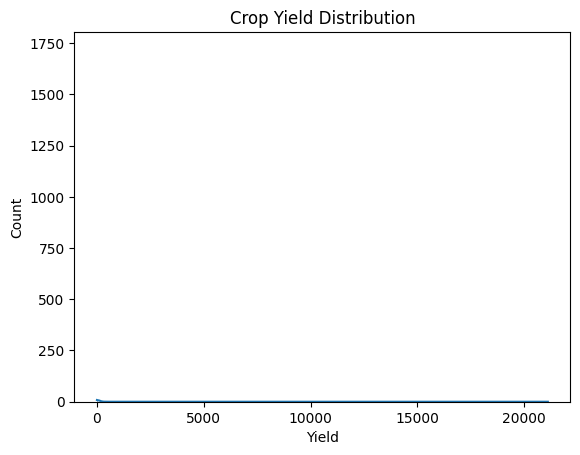

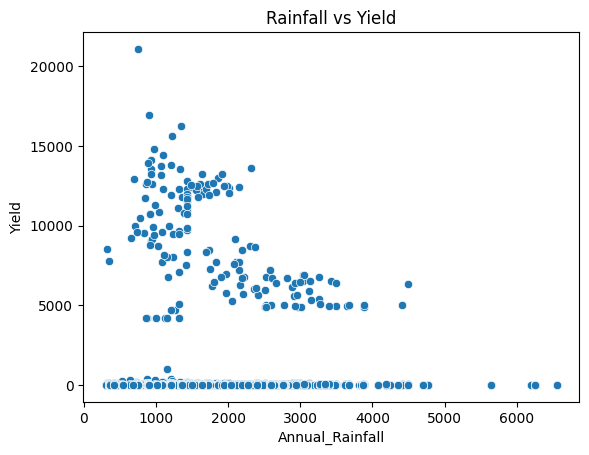

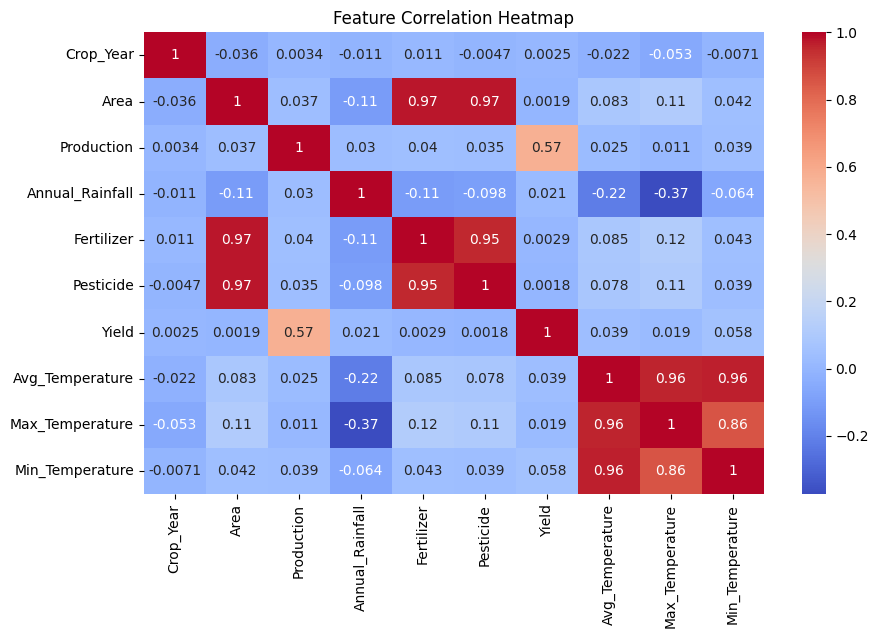

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Yield distribution
plt.figure()
sns.histplot(df['Yield'], kde=True)
plt.title("Crop Yield Distribution")
plt.show()

# Rainfall vs Yield
plt.figure()
sns.scatterplot(x=df['Annual_Rainfall'], y=df['Yield'])
plt.title("Rainfall vs Yield")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

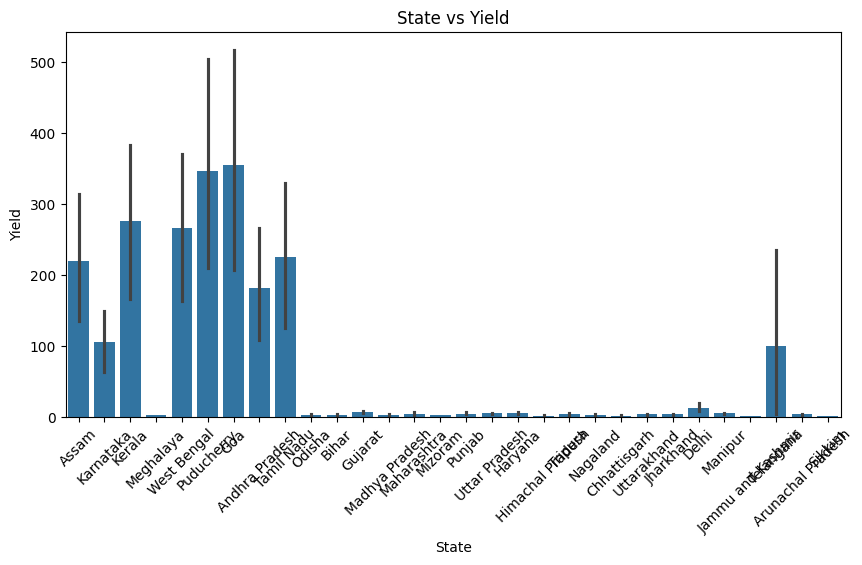

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.barplot(x='State', y='Yield', data=df)
plt.xticks(rotation=45)
plt.title("State vs Yield")
plt.show()

In [39]:
from sklearn.model_selection import train_test_split

df = df.dropna()

X = df.drop("Yield", axis=1)
y = df["Yield"]

# convert categorical if needed
X = pd.get_dummies(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9651885223875935
MAE: 10.38949238953783


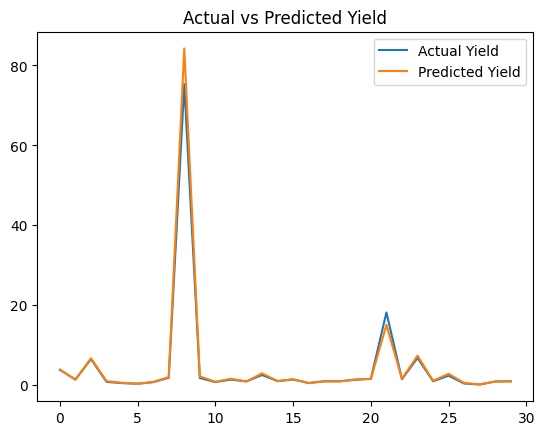

In [41]:
plt.figure()
plt.plot(y_test.values[:30], label="Actual Yield")
plt.plot(y_pred[:30], label="Predicted Yield")
plt.legend()
plt.title("Actual vs Predicted Yield")
plt.show()